# Introduction: Tracking with polar measurements and a Cartesian state
The output from this notebook will be used to provide answers for this lesson's practice
quiz. It implements code to convert polar measurements to Cartesian.

In [1]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

r = 5000;       % true range of 5000m
q = pi/4;       % true bearing = q
sigmaR = 1;     % std deviation of r, m
sigmaQ = pi/64; % std deviation of bearing

In [2]:
% Compute the true [x,y] Cartesian position of the target
Ztrue = [r*cos(q); r*sin(q)]

% Compute the true mean error of [x_m,y_m] if r,q known
vbar  = [r*cos(q)*(exp(-sigmaQ^2/2)-1); 
         r*sin(q)*(exp(-sigmaQ^2/2)-1)]; 
         
% Compute the true values of the converted measurement covariance         
% (We don't use this result in this lab, but this is how to compute it)
S11   = r^2*exp(-sigmaQ^2)*((cos(q))^2*(cosh(sigmaQ^2)-1)+(sin(q))^2*sinh(sigmaQ^2)) ...
         +sigmaR^2*exp(-sigmaQ^2)*((cos(q))^2*cosh(sigmaQ^2)+(sin(q))^2*sinh(sigmaQ^2));
S12   = sin(q)*cos(q)*exp(-2*sigmaQ^2)*(sigmaR^2+r^2*(1-exp(sigmaQ^2)));
S22   = r^2*exp(-sigmaQ^2)*((sin(q))^2*(cosh(sigmaQ^2)-1)+(cos(q))^2*sinh(sigmaQ^2)) ...
         +sigmaR^2*exp(-sigmaQ^2)*((sin(q))^2*cosh(sigmaQ^2)+(cos(q)^2)*sinh(sigmaQ^2));
S     = [S11 S12; S12 S22]; % true covariance if r,q known

Ztrue =

   3535.5
   3535.5



In [3]:
% Do not change the next line that sets the randn "seed"... otherwise the results
% will not match what is expected by the quiz
randn("seed",1); 

% Compute N random measurements of range and bearing
N = 10000;
rm = r + sigmaR*randn(1,N);
qm = q + sigmaQ*randn(1,N);

% Compute the "naive" estimate of [x,y] for each of the N points
Znaive = [rm.*cos(qm); rm.*sin(qm)];
% Compute the average naive estimate
ZbarNaive = mean(Znaive,2)

ZbarNaive =

   3530.9
   3531.6



In [5]:
% Compute the corrected Cartesian measurements
Zfix = [rm.*cos(qm)*(1-exp(-sigmaQ^2)+exp(-sigmaQ^2/2));
        rm.*sin(qm)*(1-exp(-sigmaQ^2)+exp(-sigmaQ^2/2))];
% Compute the average corrected Cartesian measurement
ZbarFix = mean(Zfix,2)

% Compute the corrected measurement covariance  
% (We don't use this result in this lab, but this is how to compute it)
S11a = rm.^2*exp(-2*sigmaQ^2).*((cos(qm)).^2.*(cosh(2*sigmaQ^2)-cosh(sigmaQ^2)) ...
       +(sin(qm)).^2.*(sinh(2*sigmaQ^2)-sinh(sigmaQ^2))) ...
       +sigmaR^2*exp(-2*sigmaQ^2)*((cos(qm)).^2.*(2*cosh(2*sigmaQ^2)-cosh(sigmaQ^2)) ...
       +(sin(qm)).^2.*(2*sinh(2*sigmaQ^2)-sinh(sigmaQ^2)));
S12a = sin(qm).*cos(qm).*exp(-4*sigmaQ^2).*(sigmaR^2+(rm.^2+sigmaR^2)*(1-exp(sigmaQ^2)));
S22a = rm.^2*exp(-2*sigmaQ^2).*((sin(qm)).^2.*(cosh(2*sigmaQ^2)-cosh(sigmaQ^2)) ...
       +(cos(qm)).^2.*(sinh(2*sigmaQ^2)-sinh(sigmaQ^2)))...
       +sigmaR^2*exp(-2*sigmaQ^2)*((sin(qm)).^2.*(2*cosh(2*sigmaQ^2)-cosh(sigmaQ^2))...
       +(cos(qm)).^2.*(2*sinh(2*sigmaQ^2)-sinh(sigmaQ^2)));
Sa = [mean(S11a) mean(S12a); mean(S12a) mean(S22a)];

ZbarFix =

   3535.1
   3535.9



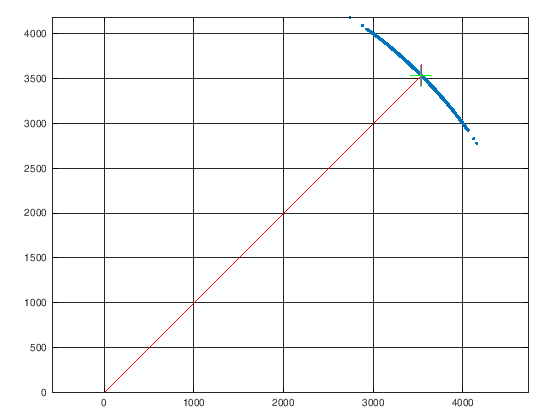

In [6]:
% Plot the measured data points
plot(rm.*cos(qm),rm.*sin(qm),'.'); hold on; grid on
% Plot the line from the origin (the sensor location) to the true target location
plot([0 Ztrue(1)],[0 Ztrue(2)],'r');
% Plot the two estimates
plot(ZbarFix(1),ZbarFix(2),'m+','markersize',20)
plot(ZbarNaive(1),ZbarNaive(2),'g+','markersize',20)
axis("equal")

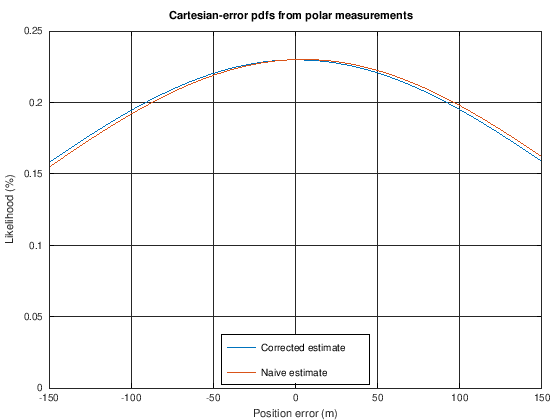

In [7]:
% Plot approximate error pdfs
errNaive = Ztrue - Znaive;
errFix   = Ztrue - Zfix;

x = -300:300;
plot(x,100*normpdf(x,mean(errFix(1,:)),std(errFix(1,:)))); hold on
plot(x,100*normpdf(x,mean(errNaive(1,:)),std(errNaive(1,:)))); 
grid on; xlim([-150 150])
title('Cartesian-error pdfs from polar measurements   ');
xlabel('Position error (m)');
ylabel('Likelihood (%)');
legend('Corrected estimate','Naive estimate','location','south');